In [1]:
# ==========================================
# Credit Card Default Risk Prediction
# ==========================================

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)


# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# Load Dataset

df = pd.read_csv("C:/Users/manish gupta/OneDrive/Documents/GitHub/Credit-Card-Default-Prediction/dataset/UCI_Credit_Card.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# Display First Five Rows

df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [5]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 30000
Columns : 25


In [6]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default.payment.next.month']


In [7]:
df.rename(
    columns={
        "default.payment.next.month": "default_payment"
    },
    inplace=True
)

print("Target column renamed successfully.")

Target column renamed successfully.


In [8]:
df.rename(
    columns={
        "PAY_0": "PAY_1"
    },
    inplace=True
)

print("PAY columns renamed.")

PAY columns renamed.


In [9]:
print("Total Missing Values :", df.isnull().sum().sum())

Total Missing Values : 0


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

Duplicate Rows : 0


In [11]:
df = df.drop_duplicates()

print("New Shape :", df.shape)

New Shape : (30000, 25)


In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_1,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


In [13]:
print(df["EDUCATION"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
5      280
4      123
6       51
0       14
Name: count, dtype: int64


In [14]:
df["EDUCATION"] = df["EDUCATION"].replace({
    0:4,
    5:4,
    6:4
})

print(df["EDUCATION"].value_counts())

EDUCATION
2    14030
1    10585
3     4917
4      468
Name: count, dtype: int64


In [15]:
print(df["MARRIAGE"].value_counts())

MARRIAGE
2    15964
1    13659
3      323
0       54
Name: count, dtype: int64


In [16]:
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0:3
})

print(df["MARRIAGE"].value_counts())

MARRIAGE
2    15964
1    13659
3      377
Name: count, dtype: int64


In [17]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_payment
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


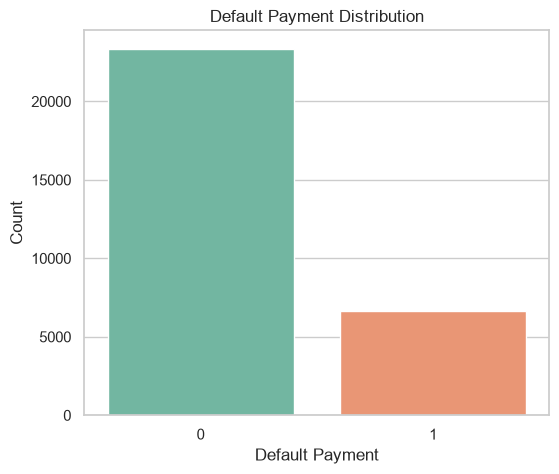

In [18]:
# Default Distribution

plt.figure(figsize=(6,5))

sns.countplot(
    x="default_payment",
    data=df,
    palette="Set2"
)

plt.title("Default Payment Distribution")
plt.xlabel("Default Payment")
plt.ylabel("Count")

plt.savefig("default_distribution.png")

plt.show()

In [19]:
default_rate = df["default_payment"].value_counts(normalize=True) * 100

print(default_rate)

default_payment
0    77.88
1    22.12
Name: proportion, dtype: float64


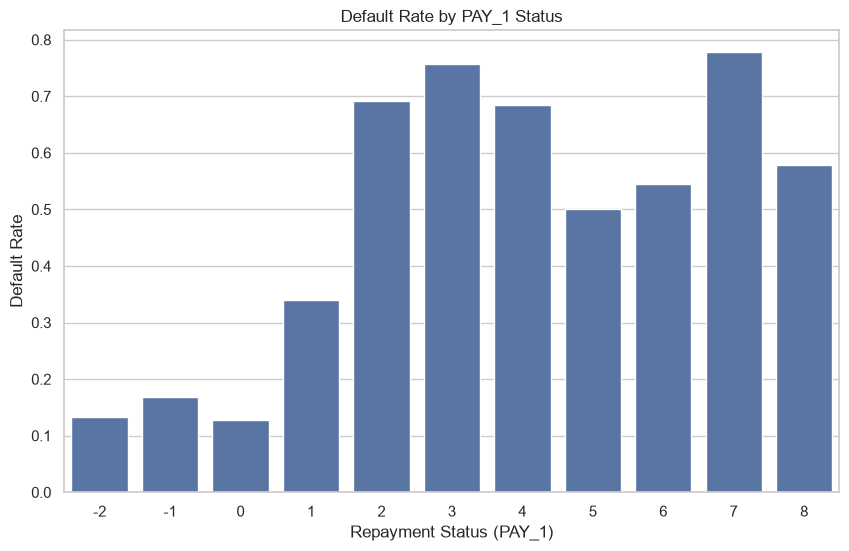

In [20]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="PAY_1",
    y="default_payment",
    data=df,
    estimator=np.mean,
    errorbar=None
)

plt.title("Default Rate by PAY_1 Status")
plt.xlabel("Repayment Status (PAY_1)")
plt.ylabel("Default Rate")

plt.savefig("pay1_default_rate.png")

plt.show()

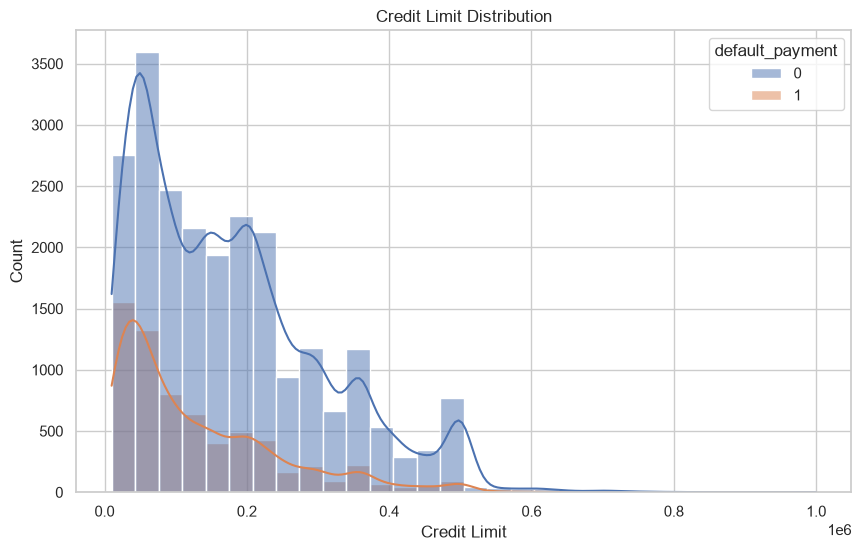

In [21]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="LIMIT_BAL",
    hue="default_payment",
    bins=30,
    kde=True
)

plt.title("Credit Limit Distribution")
plt.xlabel("Credit Limit")
plt.ylabel("Count")

plt.savefig("limit_bal_distribution.png")

plt.show()

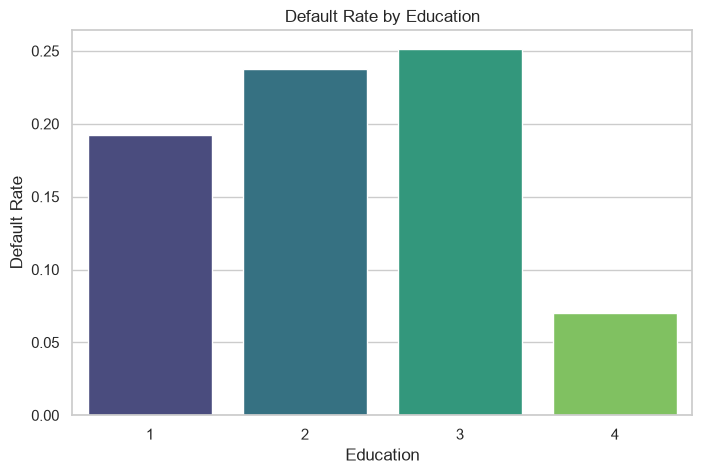

In [22]:
education_default = (
    df.groupby("EDUCATION")["default_payment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="EDUCATION",
    y="default_payment",
    data=education_default,
    palette="viridis"
)

plt.title("Default Rate by Education")

plt.xlabel("Education")

plt.ylabel("Default Rate")

plt.savefig("education_default.png")

plt.show()

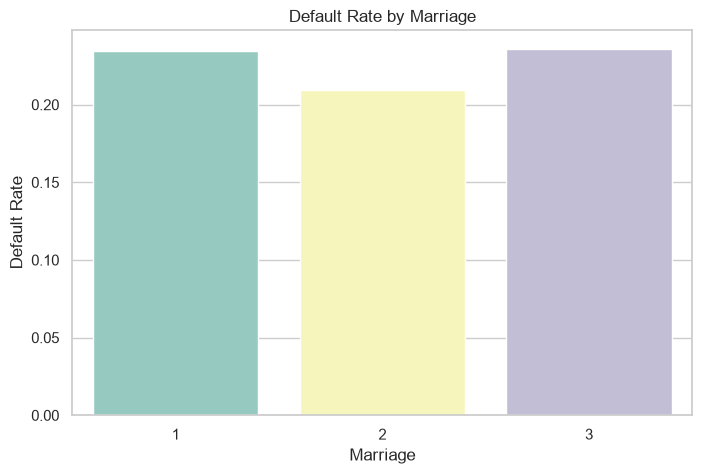

In [23]:
marriage_default = (
    df.groupby("MARRIAGE")["default_payment"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    x="MARRIAGE",
    y="default_payment",
    data=marriage_default,
    palette="Set3"
)

plt.title("Default Rate by Marriage")

plt.xlabel("Marriage")

plt.ylabel("Default Rate")

plt.savefig("marriage_default.png")

plt.show()

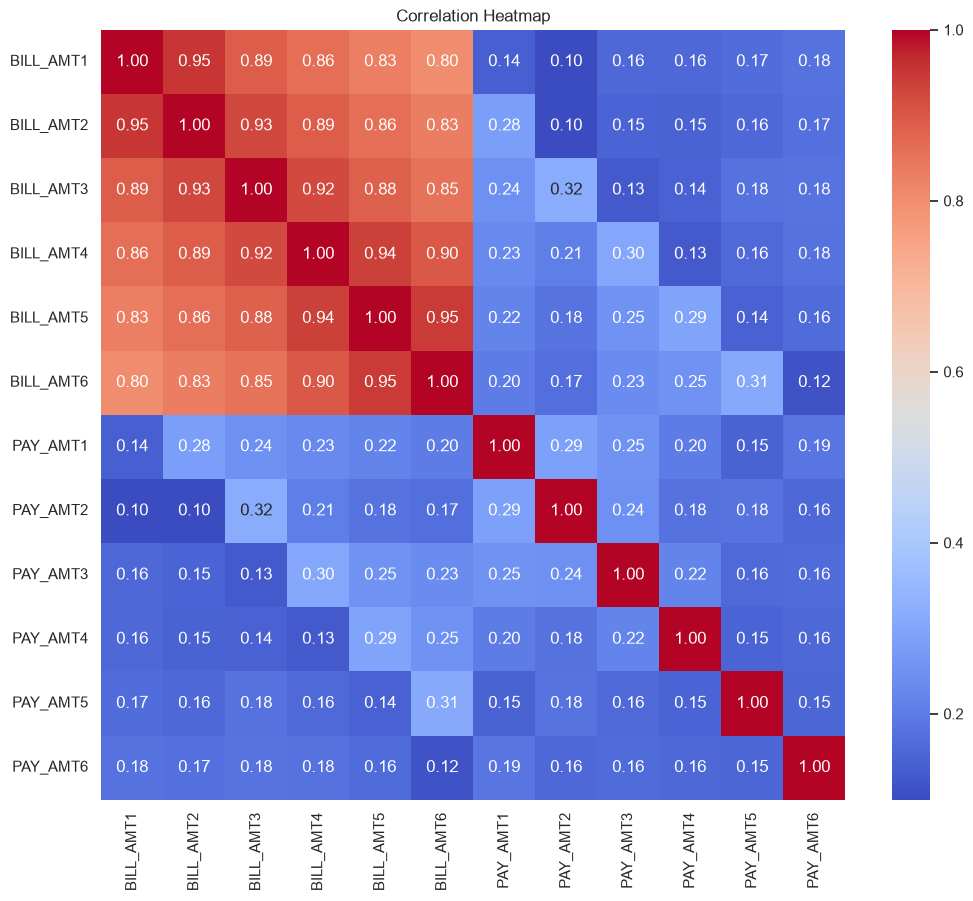

In [24]:
bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

pay_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

corr = df[bill_columns + pay_columns].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

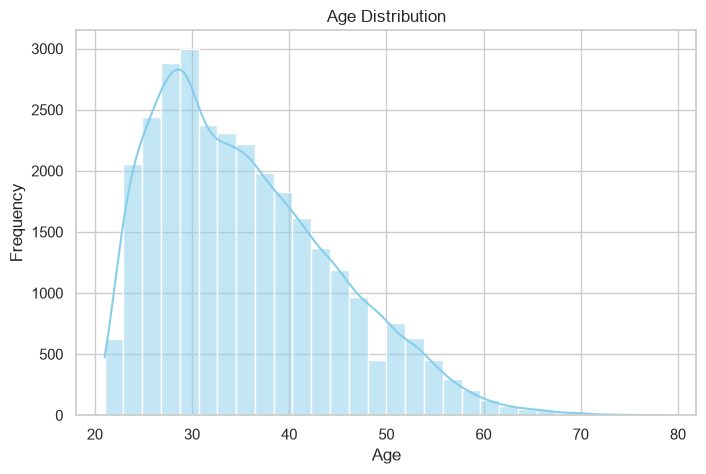

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["AGE"],
    bins=30,
    kde=True,
    color="skyblue"
)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.savefig("age_distribution.png")

plt.show()

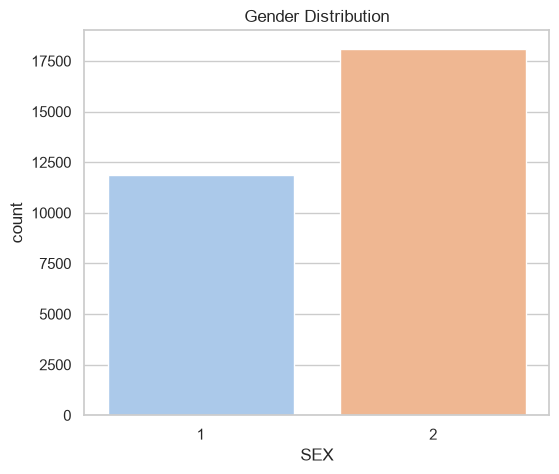

In [26]:
plt.figure(figsize=(6,5))

sns.countplot(
    x="SEX",
    data=df,
    palette="pastel"
)

plt.title("Gender Distribution")

plt.savefig("gender_distribution.png")

plt.show()

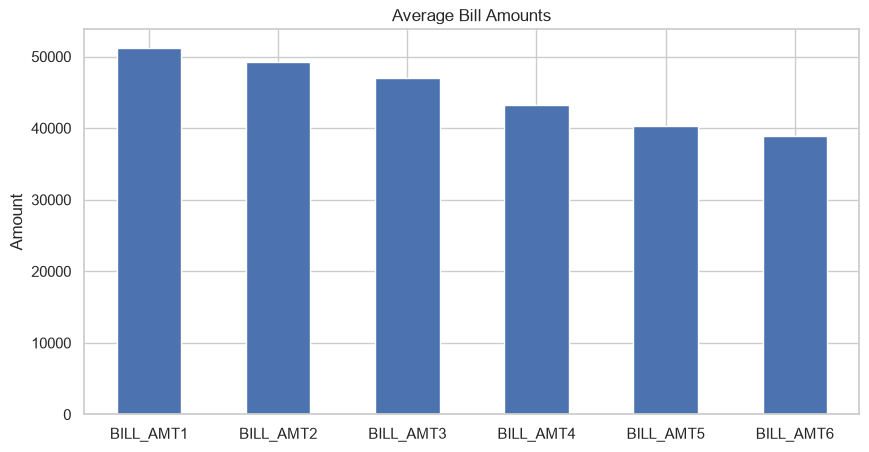

In [27]:
average_bill = df[bill_columns].mean()

plt.figure(figsize=(10,5))

average_bill.plot(kind="bar")

plt.title("Average Bill Amounts")

plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.savefig("average_bill_amount.png")

plt.show()

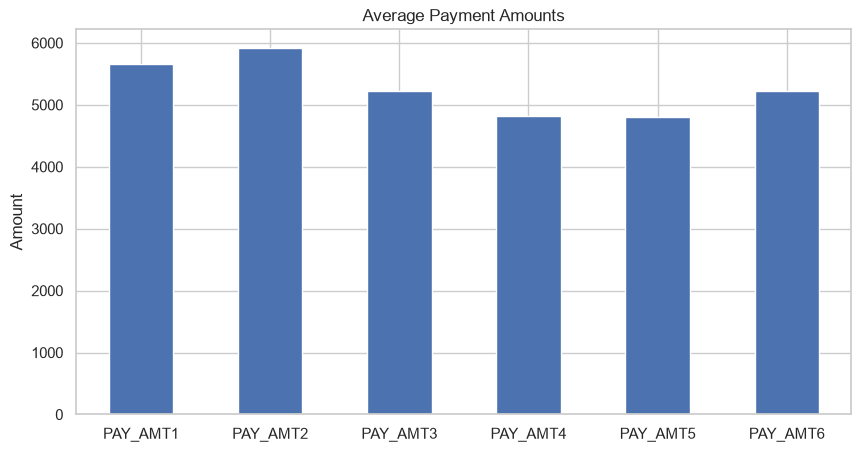

In [28]:
average_payment = df[pay_columns].mean()

plt.figure(figsize=(10,5))

average_payment.plot(kind="bar")

plt.title("Average Payment Amounts")

plt.ylabel("Amount")

plt.xticks(rotation=0)

plt.savefig("average_payment_amount.png")

plt.show()

In [29]:
# Create Average Bill Amount

bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

df["avg_bill_amt"] = df[bill_columns].mean(axis=1)

df[["avg_bill_amt"]].head()

,avg_bill_amt
0,1284.000000
1,2846.166667
2,16942.166667
3,38555.666667
4,18223.166667


In [30]:
# Create Average Payment Amount

pay_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df["avg_pay_amt"] = df[pay_columns].mean(axis=1)

df[["avg_pay_amt"]].head()

,avg_pay_amt
0,114.833333
1,833.333333
2,1836.333333
3,1398.000000
4,9841.500000


In [31]:
# Create Payment to Bill Ratio

df["pay_to_bill_ratio"] = (
    df["avg_pay_amt"] /
    (df["avg_bill_amt"] + 1)
)

df[["pay_to_bill_ratio"]].head()

,pay_to_bill_ratio
0,0.089364
1,0.292689
2,0.108382
3,0.036258
4,0.540025


In [32]:
# Maximum Repayment Delay

delay_columns = [
    "PAY_1",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df["max_delay"] = df[delay_columns].max(axis=1)

df[["max_delay"]].head()

,max_delay
0,2
1,2
2,0
3,0
4,0


In [33]:
new_features = [
    "avg_bill_amt",
    "avg_pay_amt",
    "pay_to_bill_ratio",
    "max_delay"
]

df[new_features].head()

,avg_bill_amt,avg_pay_amt,pay_to_bill_ratio,max_delay
0,1284.000000,114.833333,0.089364,2
1,2846.166667,833.333333,0.292689,2
2,16942.166667,1836.333333,0.108382,0
3,38555.666667,1398.000000,0.036258,0
4,18223.166667,9841.500000,0.540025,0


In [34]:
# Target Variable

y = df["default_payment"]

print(y.head())

0    1
1    1
2    0
3    0
4    0
Name: default_payment, dtype: int64


In [35]:
# Remove Target Column

X = df.drop("default_payment", axis=1)

print(X.shape)

(30000, 28)


In [36]:
print(X.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'avg_bill_amt', 'avg_pay_amt', 'pay_to_bill_ratio', 'max_delay']


In [37]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE"
]

categorical_features

['SEX', 'EDUCATION', 'MARRIAGE']

In [38]:
numerical_features = X.drop(
    columns=categorical_features
).columns.tolist()

numerical_features

['ID',
 'LIMIT_BAL',
 'AGE',
 'PAY_1',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'avg_bill_amt',
 'avg_pay_amt',
 'pay_to_bill_ratio',
 'max_delay']

In [39]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

print("Preprocessor Created")

Preprocessor Created


In [40]:
print("Numerical Features")

print(numerical_features)

print()

print("Categorical Features")

print(categorical_features)

Numerical Features
['ID', 'LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'avg_bill_amt', 'avg_pay_amt', 'pay_to_bill_ratio', 'max_delay']

Categorical Features
['SEX', 'EDUCATION', 'MARRIAGE']


In [41]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(skf)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


In [42]:
print(df["default_payment"].value_counts())

print()

print(df["default_payment"].value_counts(normalize=True))

default_payment
0    23364
1     6636
Name: count, dtype: int64

default_payment
0    0.7788
1    0.2212
Name: proportion, dtype: float64


In [43]:
from sklearn.pipeline import Pipeline

In [44]:
# Logistic Regression Pipeline

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression Pipeline Created")

Logistic Regression Pipeline Created


In [45]:
# Decision Tree Pipeline

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=6,
                random_state=42
            )
        )
    ]
)

print("Decision Tree Pipeline Created")

Decision Tree Pipeline Created


In [46]:
# Random Forest Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

print("Random Forest Pipeline Created")

Random Forest Pipeline Created


In [47]:
# Evaluation Metrics

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

In [48]:
def evaluate_model(model, model_name):
    """
    Evaluate model using Stratified K-Fold Cross Validation
    """

    scores = cross_validate(
        estimator=model,
        X=X,
        y=y,
        cv=skf,
        scoring=scoring,
        return_train_score=False
    )

    result = {
        "Model": model_name,

        "Accuracy Mean": scores["test_accuracy"].mean(),
        "Accuracy Std": scores["test_accuracy"].std(),

        "Precision Mean": scores["test_precision"].mean(),
        "Precision Std": scores["test_precision"].std(),

        "Recall Mean": scores["test_recall"].mean(),
        "Recall Std": scores["test_recall"].std(),

        "F1 Mean": scores["test_f1"].mean(),
        "F1 Std": scores["test_f1"].std(),

        "ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "ROC-AUC Std": scores["test_roc_auc"].std(),

        "F1 Scores": scores["test_f1"]
    }

    return result

In [49]:
logistic_result = evaluate_model(
    logistic_pipeline,
    "Logistic Regression"
)

print(logistic_result)

{'Model': 'Logistic Regression', 'Accuracy Mean': np.float64(nan), 'Accuracy Std': np.float64(nan), 'Precision Mean': np.float64(nan), 'Precision Std': np.float64(nan), 'Recall Mean': np.float64(nan), 'Recall Std': np.float64(nan), 'F1 Mean': np.float64(nan), 'F1 Std': np.float64(nan), 'ROC-AUC Mean': np.float64(nan), 'ROC-AUC Std': np.float64(nan), 'F1 Scores': array([nan, nan, nan, nan, nan])}


In [50]:
decision_tree_result = evaluate_model(
    decision_tree_pipeline,
    "Decision Tree"
)

print(decision_tree_result)

{'Model': 'Decision Tree', 'Accuracy Mean': np.float64(0.8186666666666665), 'Accuracy Std': np.float64(0.003894440481849311), 'Precision Mean': np.float64(0.67221652345568), 'Precision Std': np.float64(0.025497408755415524), 'Recall Mean': np.float64(0.35367562942047015), 'Recall Std': np.float64(0.009679328671347914), 'F1 Mean': np.float64(0.46316387779275675), 'F1 Std': np.float64(0.0077632629601724155), 'ROC-AUC Mean': np.float64(0.7653684478531627), 'ROC-AUC Std': np.float64(0.006463665527350495), 'F1 Scores': array([0.46949732, 0.45038911, 0.4675835 , 0.4579918 , 0.47035767])}


In [51]:
random_forest_result = evaluate_model(
    random_forest_pipeline,
    "Random Forest"
)

print(random_forest_result)

{'Model': 'Random Forest', 'Accuracy Mean': np.float64(0.8173333333333334), 'Accuracy Std': np.float64(0.0032455097185701645), 'Precision Mean': np.float64(0.6555821182229165), 'Precision Std': np.float64(0.015113054658743127), 'Recall Mean': np.float64(0.36739043589580633), 'Recall Std': np.float64(0.004153998720329025), 'F1 Mean': np.float64(0.4708675736664449), 'F1 Std': np.float64(0.007024260715055218), 'ROC-AUC Mean': np.float64(0.7691631491080783), 'ROC-AUC Std': np.float64(0.006421317656135975), 'F1 Scores': array([0.46831156, 0.46286536, 0.47424684, 0.48279205, 0.46612206])}


In [52]:
results = [
    logistic_result,
    decision_tree_result,
    random_forest_result
]

In [53]:
comparison_df = pd.DataFrame({
    "Model": [
        result["Model"]
        for result in results
    ],

    "Accuracy":
    [
        f"{result['Accuracy Mean']:.4f} ± {result['Accuracy Std']:.4f}"
        for result in results
    ],

    "Precision":
    [
        f"{result['Precision Mean']:.4f} ± {result['Precision Std']:.4f}"
        for result in results
    ],

    "Recall":
    [
        f"{result['Recall Mean']:.4f} ± {result['Recall Std']:.4f}"
        for result in results
    ],

    "F1 Score":
    [
        f"{result['F1 Mean']:.4f} ± {result['F1 Std']:.4f}"
        for result in results
    ],

    "ROC-AUC":
    [
        f"{result['ROC-AUC Mean']:.4f} ± {result['ROC-AUC Std']:.4f}"
        for result in results
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,nan ± nan,nan ± nan,nan ± nan,nan ± nan,nan ± nan
1,Decision Tree,0.8187 ± 0.0039,0.6722 ± 0.0255,0.3537 ± 0.0097,0.4632 ± 0.0078,0.7654 ± 0.0065
2,Random Forest,0.8173 ± 0.0032,0.6556 ± 0.0151,0.3674 ± 0.0042,0.4709 ± 0.0070,0.7692 ± 0.0064


In [54]:
comparison_df = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,nan ± nan,nan ± nan,nan ± nan,nan ± nan,nan ± nan
2,Random Forest,0.8173 ± 0.0032,0.6556 ± 0.0151,0.3674 ± 0.0042,0.4709 ± 0.0070,0.7692 ± 0.0064
1,Decision Tree,0.8187 ± 0.0039,0.6722 ± 0.0255,0.3537 ± 0.0097,0.4632 ± 0.0078,0.7654 ± 0.0065


In [55]:
print(comparison_df)

                 Model         Accuracy        Precision           Recall  \
0  Logistic Regression        nan ± nan        nan ± nan        nan ± nan   
2        Random Forest  0.8173 ± 0.0032  0.6556 ± 0.0151  0.3674 ± 0.0042   
1        Decision Tree  0.8187 ± 0.0039  0.6722 ± 0.0255  0.3537 ± 0.0097   

          F1 Score          ROC-AUC  
0        nan ± nan        nan ± nan  
2  0.4709 ± 0.0070  0.7692 ± 0.0064  
1  0.4632 ± 0.0078  0.7654 ± 0.0065  


In [56]:
comparison_df.to_csv(
    "model_comparison.csv",
    index=False
)

print("Comparison Table Saved")

Comparison Table Saved


In [57]:
for result in results:

    print("="*60)

    print(result["Model"])

    print("="*60)

    print(
        f"Accuracy : {result['Accuracy Mean']:.4f} ± {result['Accuracy Std']:.4f}"
    )

    print(
        f"Precision : {result['Precision Mean']:.4f} ± {result['Precision Std']:.4f}"
    )

    print(
        f"Recall : {result['Recall Mean']:.4f} ± {result['Recall Std']:.4f}"
    )

    print(
        f"F1 Score : {result['F1 Mean']:.4f} ± {result['F1 Std']:.4f}"
    )

    print(
        f"ROC-AUC : {result['ROC-AUC Mean']:.4f} ± {result['ROC-AUC Std']:.4f}"
    )

    print()

Logistic Regression
Accuracy : nan ± nan
Precision : nan ± nan
Recall : nan ± nan
F1 Score : nan ± nan
ROC-AUC : nan ± nan

Decision Tree
Accuracy : 0.8187 ± 0.0039
Precision : 0.6722 ± 0.0255
Recall : 0.3537 ± 0.0097
F1 Score : 0.4632 ± 0.0078
ROC-AUC : 0.7654 ± 0.0065

Random Forest
Accuracy : 0.8173 ± 0.0032
Precision : 0.6556 ± 0.0151
Recall : 0.3674 ± 0.0042
F1 Score : 0.4709 ± 0.0070
ROC-AUC : 0.7692 ± 0.0064



In [58]:
# Hyperparameter Grid

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_split": [2, 5]
}

param_grid

{'model__n_estimators': [100, 200],
 'model__max_depth': [5, 10, None],
 'model__min_samples_split': [2, 5]}

In [59]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=skf,
    n_jobs=-1,
    verbose=1
)

print("GridSearchCV Created")

GridSearchCV Created


In [60]:
grid_search.fit(X, y)

print("Grid Search Completed")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Grid Search Completed


In [61]:
print("Best Parameters")

print(grid_search.best_params_)

Best Parameters
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}


In [62]:
best_model = grid_search.best_estimator_

best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['ID', 'LIMIT_BAL', 'AGE',
                                                   'PAY_1', 'PAY_2', 'PAY_3',
                                                   'PAY_4', 'PAY_5', 'PAY_6',
                                                   'BILL_AMT1', 'BILL_AMT2',
                                                   'BILL_AMT3', 'BILL_AMT4',
                                                   'BILL_AMT5', 'BILL_AMT6',
                                                   'PAY_AMT1', 'PAY_AMT2',
                                                   'PAY_AMT3', 'PAY_AMT4',
                                                   'PAY_AMT5', 'PAY_AMT6',
                                                   'avg_bill_amt',
                                                   'avg_pay_amt',
                                                   'pay_to_bill_ratio',
                                                   'max_delay']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['SEX', 'EDUCATION',
                                                   'MARRIAGE'])],
                                   verbose_feature_names_out=False)),
                ('model',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

In [63]:
tuned_scores = cross_validate(
    estimator=best_model,
    X=X,
    y=y,
    cv=skf,
    scoring=scoring
)

print("Evaluation Completed")

Evaluation Completed


In [64]:
print("Accuracy")

print(
    tuned_scores["test_accuracy"].mean(),
    "+/-",
    tuned_scores["test_accuracy"].std()
)

print()

print("Precision")

print(
    tuned_scores["test_precision"].mean(),
    "+/-",
    tuned_scores["test_precision"].std()
)

print()

print("Recall")

print(
    tuned_scores["test_recall"].mean(),
    "+/-",
    tuned_scores["test_recall"].std()
)

print()

print("F1 Score")

print(
    tuned_scores["test_f1"].mean(),
    "+/-",
    tuned_scores["test_f1"].std()
)

print()

print("ROC-AUC")

print(
    tuned_scores["test_roc_auc"].mean(),
    "+/-",
    tuned_scores["test_roc_auc"].std()
)

Accuracy
0.8188333333333333 +/- 0.00362705880232944

Precision
0.6603716115382221 +/- 0.015562249283089986

Recall
0.3728148464241291 +/- 0.007275186349809259

F1 Score
0.4765592774641688 +/- 0.009623103709975291

ROC-AUC
0.7699872422909502 +/- 0.006375737211419303


In [65]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "Tuned Random Forest"
    ],

    "F1 Score":[

        random_forest_result["F1 Mean"],

        tuned_scores["test_f1"].mean()

    ],

    "ROC AUC":[

        random_forest_result["ROC-AUC Mean"],

        tuned_scores["test_roc_auc"].mean()

    ]

})

comparison

,Model,F1 Score,ROC AUC
0,Random Forest,0.470868,0.769163
1,Tuned Random Forest,0.476559,0.769987


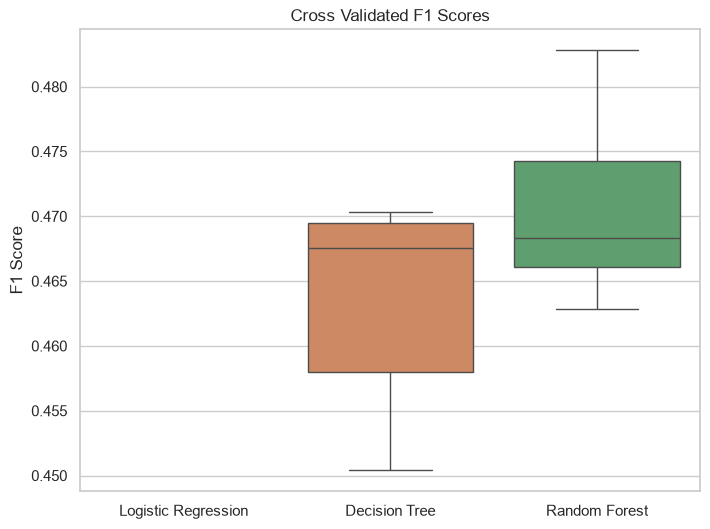

In [66]:
boxplot_df = pd.DataFrame({

    "Logistic Regression": logistic_result["F1 Scores"],

    "Decision Tree": decision_tree_result["F1 Scores"],

    "Random Forest": random_forest_result["F1 Scores"]

})

plt.figure(figsize=(8,6))

sns.boxplot(data=boxplot_df)

plt.title("Cross Validated F1 Scores")

plt.ylabel("F1 Score")

plt.savefig("f1_boxplot.png")

plt.show()

In [67]:
predictions = cross_val_predict(

    best_model,

    X,

    y,

    cv=skf

)

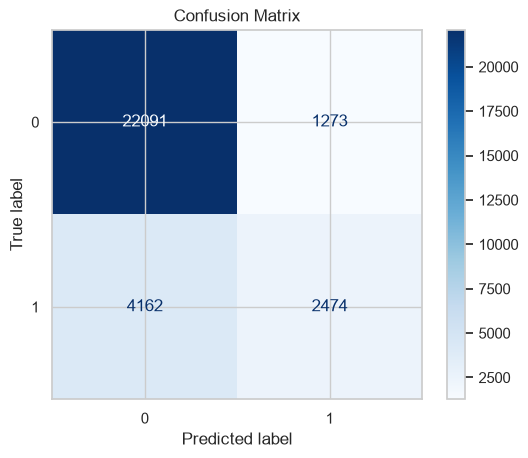

In [68]:
cm = confusion_matrix(y, predictions)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm

)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png")

plt.show()

In [69]:
print(

    classification_report(

        y,

        predictions

    )

)

              precision    recall  f1-score   support

           0       0.84      0.95      0.89     23364
           1       0.66      0.37      0.48      6636

    accuracy                           0.82     30000
   macro avg       0.75      0.66      0.68     30000
weighted avg       0.80      0.82      0.80     30000



In [70]:
best_model.fit(X, y)

print("Training Completed")

Training Completed


In [71]:
# Get transformed feature names

encoded_columns = best_model.named_steps["preprocessor"]\
.named_transformers_["cat"]\
.get_feature_names_out(categorical_features)

feature_names = np.concatenate(

    [

        numerical_features,

        encoded_columns

    ]

)

importance = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": importance

})

importance_df = importance_df.sort_values(

    by="Importance",

    ascending=False

)

importance_df.head(15)

,Feature,Importance
3,PAY_1,0.080886
24,max_delay,0.057772
0,ID,0.056834
22,avg_pay_amt,0.047278
23,pay_to_bill_ratio,0.046672
2,AGE,0.045185
21,avg_bill_amt,0.042510
1,LIMIT_BAL,0.042483
9,BILL_AMT1,0.042154
10,BILL_AMT2,0.039039


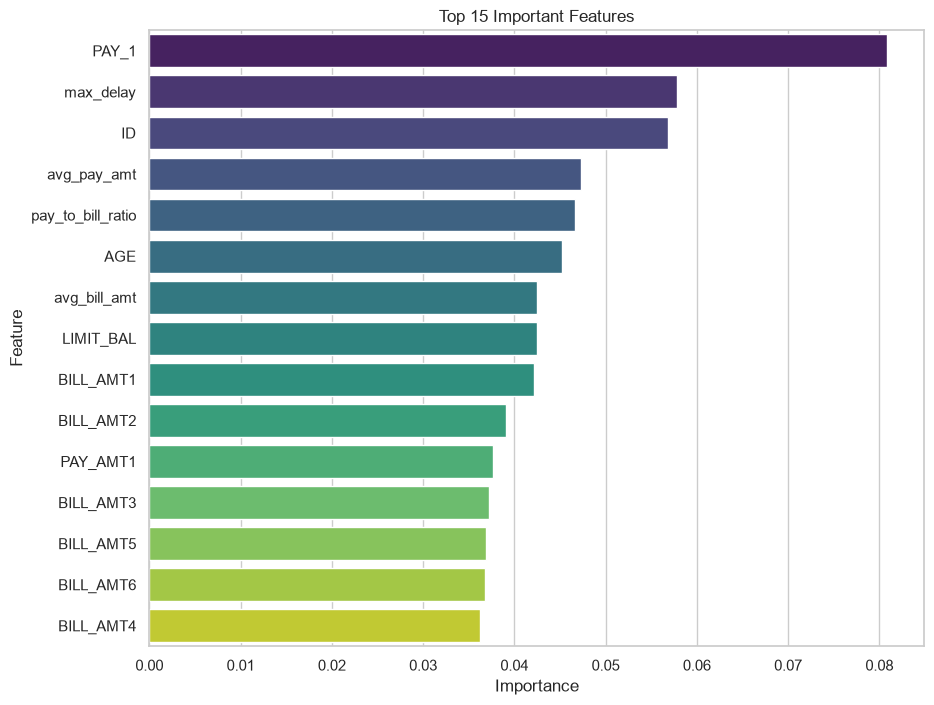

In [72]:
top_features = importance_df.head(15)

plt.figure(figsize=(10,8))

sns.barplot(

    x="Importance",

    y="Feature",

    data=top_features,

    palette="viridis"

)

plt.title("Top 15 Important Features")

plt.savefig("feature_importance.png")

plt.show()

In [75]:
import os
import pickle

os.makedirs("models", exist_ok=True)

with open("models/model.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Model saved successfully!")

Model saved successfully!


In [76]:
import pickle

with open("models/feature_columns.pkl", "wb") as file:
    pickle.dump(X.columns.tolist(), file)

print("Feature Columns Saved Successfully")

Feature Columns Saved Successfully
